todo: focus on antibody table first

Antibody response over time

Difference between males, females. young, old

So want a format that lets you plot the data to start
--

we would save lives if we could answer the project questions

We want to do better than 'the vaccine worked well based on survival'. Models that can predict if a vaccine is good = can save a lot of effort and lives

--

Look up previous dse project submitted for pertussis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_PATH = 'data/PART2-26-01-26_reorg/PART2-26-01-26_reorg'
# # Files for the challenge
# challenge_flow = pd.read_csv(DATA_PATH + "/challenge_flow.tsv", sep='\t')
# challenge_hai = pd.read_csv(DATA_PATH + "/challenge_hai.tsv", sep='\t')
# challenge_participants = pd.read_csv(DATA_PATH + "/challenge_participants.tsv", sep='\t')
# challenge_transcriptomics = pd.read_csv(DATA_PATH + "/challenge_transcriptomics.tsv", sep='\t')
# Files for training
train_array = pd.read_csv(DATA_PATH + "/train_array.tsv", sep='\t')
train_bcr = pd.read_csv(DATA_PATH + "/train_bcr.tsv", sep='\t', low_memory=False)
train_flow = pd.read_csv(DATA_PATH + "/train_flow.tsv", sep='\t', low_memory=False)
train_hai = pd.read_csv(DATA_PATH + "/train_hai.tsv", sep='\t')
train_participants = pd.read_csv(DATA_PATH + "/train_participants.tsv", sep='\t')
train_transcriptomics_2019_UGA = pd.read_csv(DATA_PATH + "/train_transcriptomics_2019_UGA.tsv", sep='\t')
train_transcriptomics_2020_UGA = pd.read_csv(DATA_PATH + "/train_transcriptomics_2020_UGA.tsv", sep='\t')
train_transcriptomics_SDY2867 = pd.read_csv(DATA_PATH + "/train_transcriptomics_SDY2867.tsv", sep='\t')
train_transcriptomics_SDY2941 = pd.read_csv(DATA_PATH + "/train_transcriptomics_SDY2941.tsv", sep='\t')

## Participants

In [3]:
train_participants.head(500)

,participant_id,subject,biological_sex,race,min_age,max_age,geolocation,investigation_id,investigation_name,arm_id,arm_name,data_source,description,basic_curation,pubmed_ids,main_pmid,main_publication_author
0,SDY269.SUB112836,SUB112836,female,White,28,28,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
1,SDY269.SUB112849,SUB112849,female,Black or African American,39,39,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
2,SDY269.SUB112854,SUB112854,male,Black or African American,46,46,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
3,SDY269.SUB112860,SUB112860,female,White,32,32,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
4,SDY269.SUB112881,SUB112881,female,Black or African American,29,29,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,SDY212.SUB134298,SUB134298,male,White,78,78,US: California,SDY212,Apoptosis and other immune biomarkers predict ...,ARM895,Cohort_2,"ImmPort, ImmuneSpace","Older participants aged 60 to 89 years, vaccin...",no,23591775 24337376 25834109 27746093 30842675 3...,23591775,Furman D (2013)
496,SDY212.SUB134305,SUB134305,female,White,86,86,US: California,SDY212,Apoptosis and other immune biomarkers predict ...,ARM895,Cohort_2,"ImmPort, ImmuneSpace","Older participants aged 60 to 89 years, vaccin...",no,23591775 24337376 25834109 27746093 30842675 3...,23591775,Furman D (2013)
497,SDY212.SUB134308,SUB134308,female,Asian,90,90,US: California,SDY212,Apoptosis and other immune biomarkers predict ...,ARM895,Cohort_2,"ImmPort, ImmuneSpace","Older participants aged 60 to 89 years, vaccin...",no,23591775 24337376 25834109 27746093 30842675 3...,23591775,Furman D (2013)
498,SDY212.SUB134310,SUB134310,female,White,61,61,US: California,SDY212,Apoptosis and other immune biomarkers predict ...,ARM895,Cohort_2,"ImmPort, ImmuneSpace","Older participants aged 60 to 89 years, vaccin...",no,23591775 24337376 25834109 27746093 30842675 3...,23591775,Furman D (2013)


## Assay

In [4]:
train_hai.head(500)

,hai_id,participant_id,timepoint,virus_strain,value,material
0,ID_001__2016_UGA_Standard_Fluzone__0__HAI__H1N...,2016_UGA.ID_001,0.0,H1N1 A/South Carolina/1/1918,20.,Unknown
1,ID_001__2016_UGA_Standard_Fluzone__21__HAI__H1...,2016_UGA.ID_001,28.0,H1N1 A/South Carolina/1/1918,40.,Unknown
2,ID_002__2016_UGA_Standard_Fluzone__0__HAI__H1N...,2016_UGA.ID_002,0.0,H1N1 A/South Carolina/1/1918,5.,Unknown
3,ID_002__2016_UGA_Standard_Fluzone__21__HAI__H1...,2016_UGA.ID_002,28.0,H1N1 A/South Carolina/1/1918,5.,Unknown
4,ID_003__2016_UGA_Standard_Fluzone__0__HAI__H1N...,2016_UGA.ID_003,0.0,H1N1 A/South Carolina/1/1918,80.,Unknown
...,...,...,...,...,...,...
495,ID_039__2016_UGA_Standard_Fluzone__0__HAI__H1N...,2016_UGA.ID_039,0.0,H1N1 A/Weiss/JY2/1943,5.,Unknown
496,ID_039__2016_UGA_Standard_Fluzone__21__HAI__H1...,2016_UGA.ID_039,28.0,H1N1 A/Weiss/JY2/1943,10.,Unknown
497,ID_039__2016_UGA_Standard_Fluzone__363__HAI__H...,2016_UGA.ID_039,365.0,H1N1 A/Weiss/JY2/1943,5.,Unknown
498,ID_040__2016_UGA_Standard_Fluzone__0__HAI__H1N...,2016_UGA.ID_040,0.0,H1N1 A/Weiss/JY2/1943,20.,Unknown


In [5]:
train_array.head(500)

,marray_id,participant_id,timepoint,gene_symbol,value,platform_id,material
0,BS_MARRAY___SDY61.SUB112830__ARM457.Day0__A1BG,SDY61.SUB112830,0,A1BG,7.180758,GPL570,peripheral blood mononuclear cell
1,BS_MARRAY___SDY61.SUB112830__ARM457.Day3__A1BG,SDY61.SUB112830,3,A1BG,6.690095,GPL570,peripheral blood mononuclear cell
2,BS_MARRAY___SDY61.SUB112830__ARM457.Day7__A1BG,SDY61.SUB112830,7,A1BG,6.810465,GPL570,peripheral blood mononuclear cell
3,BS_MARRAY___SDY61.SUB112832__ARM457.Day0__A1BG,SDY61.SUB112832,0,A1BG,7.091945,GPL570,peripheral blood mononuclear cell
4,BS_MARRAY___SDY61.SUB112832__ARM457.Day3__A1BG,SDY61.SUB112832,3,A1BG,6.472118,GPL570,peripheral blood mononuclear cell
...,...,...,...,...,...,...,...
495,BS_MARRAY___SDY61.SUB112835__ARM457.Day0__AAK1,SDY61.SUB112835,0,AAK1,6.854559,GPL570,peripheral blood mononuclear cell
496,BS_MARRAY___SDY61.SUB112835__ARM457.Day3__AAK1,SDY61.SUB112835,3,AAK1,6.858571,GPL570,peripheral blood mononuclear cell
497,BS_MARRAY___SDY61.SUB112835__ARM457.Day7__AAK1,SDY61.SUB112835,7,AAK1,6.961225,GPL570,peripheral blood mononuclear cell
498,BS_MARRAY___SDY61.SUB112837__ARM457.Day0__AAK1,SDY61.SUB112837,0,AAK1,6.945702,GPL570,peripheral blood mononuclear cell


In [6]:
train_flow.head(500)

,flow_id,participant_id,timepoint,parent_population,population_defnition,name,unit,value,material
0,427173,SDY180.SUB119292,-7.0,NaN,"WBC/CD19+SCC/CD19+,Freq. of,WBC",live CD45+ cells?,cells/uL,176.220000,blood
1,427174,SDY180.SUB119292,-7.0,NaN,"WBC/CD19+SCC/CD19+/nQ1: CD27,, IgD+,Freq. of,C...",Naive B cells,cells/uL,112.780800,blood
2,427175,SDY180.SUB119292,-7.0,NaN,"WBC/CD19+SCC/CD19+/nQ2: CD27+,, IgD+,Freq. of,...",Memory class switched + non-class switched B c...,cells/uL,12.370644,blood
3,427176,SDY180.SUB119292,-7.0,NaN,"WBC/CD19+SCC/CD19+/nQ3: CD27+,, IgD,Freq. of,C...",Memory class switched B cells,cells/uL,21.322620,blood
4,427177,SDY180.SUB119292,-7.0,NaN,"WBC/CD19+SCC/CD19+/nQ4: CD27,, IgD,Freq. of,CD19+",B cells,cells/uL,29.781180,blood
...,...,...,...,...,...,...,...,...,...
495,427668,SDY180.SUB119292,14.0,NaN,"WBC/2-WBC/2-grans/Neu-CD45/Neutr,Freq. of,2-WBC",Neutrophils,cells/uL,1606.400000,blood
496,427669,SDY180.SUB119292,14.0,NaN,"WBC/2-WBC/2-grans/Neu-CD45/Neutr/Q2: CD16+,, C...",live CD45+ cells?,cells/uL,1596.761600,blood
497,427670,SDY180.SUB119292,14.0,NaN,"WBC/2-WBC/2-grans/Neu-CD45/Neutr/Q3: CD16+,, C...",live CD45+ cells?,cells/uL,0.083693,blood
498,427671,SDY180.SUB119292,14.0,NaN,"WBC/2-WBC/2-grans/Neu-CD45/Neutr/Q4: CD16,, CD...",live CD45+ cells?,cells/uL,0.755008,blood


In [7]:
train_bcr.head(500)

,event_id,sequence_id,sequence,rev_comp,productive,vj_in_frame,stop_codon,locus,v_call,d_call,...,collapse_pass,collapse_count,v_germline_length,d_germline_length,j_germline_length,germline_alignment_d_mask,mu_freq,biological_sex,participant_id,material
0,BS_BCR___EXT100___P04_PBMC-ASC_d5_Y1,GTCACTCGCAGTAACGC,GCTCAGAGAGGTGCCTTAGCCCTGGATTCCAAGGCATTTCCACTTG...,False,True,True,False,IGH,IGHV3-48*01,"IGHD1-1*01,IGHD1-20*01",...,True,103,320.0,5.0,46.0,GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTACAGCCTG...,0.082111,male,EXT100.321P04,PBMCs
1,BS_BCR___EXT100___P04_PBMC-ASC_d5_Y1,CGAGGTCTCTTTTCAAT,TCTCAGAGAGGTGCCTTAGCCCTGGATTCCAAGGCATTTCCACTTG...,False,True,True,False,IGH,IGHV3-48*01,"IGHD1-1*01,IGHD1-20*01",...,True,6,320.0,5.0,46.0,GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTACAGCCTG...,0.085044,male,EXT100.321P04,PBMCs
2,BS_BCR___EXT100___P04_PBMC-ASC_d5_Y1,GTCGCTTATGCTCTAAC,GCTCAGAGAGGTGCCTTAGCCCTGGATTCCAAGGCATTTCCACTTG...,False,True,True,False,IGH,IGHV3-48*01,NaN,...,True,3,320.0,NaN,46.0,GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTACAGCCTG...,0.082111,male,EXT100.321P04,PBMCs
3,BS_BCR___EXT100___P04_PBMC-ASC_d5_Y1,ACTTGTTTATATGGGTA,GCTCAGAGAGGTGCCTTAGCCCTGGATTCCAAGGCATTTCCACTTG...,False,True,True,False,IGH,IGHV3-48*01,"IGHD1-1*01,IGHD1-20*01",...,True,8,320.0,5.0,46.0,GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTACAGCCTG...,0.085044,male,EXT100.321P04,PBMCs
4,BS_BCR___EXT100___P04_PBMC-ASC_d5_Y1,CTACGAGGGTGTCGCAA,TCTCAGAGAGGTGCCTTAGCCCTGGATTCCAAGGCATTTCCACTTG...,False,True,True,False,IGH,IGHV3-48*01,"IGHD1-1*01,IGHD1-20*01",...,True,6,320.0,5.0,46.0,GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTACAGCCTG...,0.079179,male,EXT100.321P04,PBMCs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,BS_BCR___EXT100___P04_PBMC_d0_Y1,ATCCAAAGCGGAGTGTT,GAGCTCTGGGAGAAGAGCCCCAGCCCCAGAATTCCCAGGAGTTTCC...,False,True,True,False,IGH,IGHV3-11*04,IGHD3-10*01,...,True,1,317.0,22.0,42.0,CAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTCAAGCCTG...,0.041916,male,EXT100.321P04,PBMCs
496,BS_BCR___EXT100___P04_PBMC_d0_Y1,GACTAAGCTATAGCTAC,GAGCTCTGGGAGAAGAGCCCCAGCCCCAGAATTCCCAGGAGTTTCC...,False,True,True,False,IGH,IGHV3-11*04,IGHD2-21*01,...,True,2,320.0,11.0,43.0,CAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTCAAGCCTG...,0.035503,male,EXT100.321P04,PBMCs
497,BS_BCR___EXT100___P04_PBMC_d0_Y1,ATTCCTGTCAAAAGCTT,GGCTCTGAGAGAGGAGACTTAGCCCTGGATTCCAAGGCCTATCCAC...,False,True,True,False,IGH,"IGHV3-21*01,IGHV3-21*02,IGHV3-21*05",IGHD3-10*03,...,True,4,320.0,6.0,43.0,GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCCTGGTCAAGCCTG...,0.050296,male,EXT100.321P04,PBMCs
498,BS_BCR___EXT100___P04_PBMC_d0_Y1,GAAGGAAGTGCATCTTA,AGCTCTCAGAGAGGTGCCTTAGCCCTGGATTCCAAGGCATTTCCAC...,False,True,True,False,IGH,IGHV3-48*01,IGHD4-23*01,...,True,1,320.0,8.0,48.0,GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTACAGCCTG...,0.049563,male,EXT100.321P04,PBMCs


In [8]:
train_transcriptomics_2019_UGA.head(500)

,transcriptomics_id,participant_id,timepoint,ensembl_gene_id,raw_count,tpm_count,material
0,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000000003,NaN,0.077926,Unknown
1,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000000005,NaN,0.000000,Unknown
2,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000000419,NaN,5.342548,Unknown
3,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000000457,NaN,9.799336,Unknown
4,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000000460,NaN,2.118530,Unknown
...,...,...,...,...,...,...,...
495,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000033050,NaN,24.642829,Unknown
496,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000033100,NaN,18.825870,Unknown
497,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000033122,NaN,0.159460,Unknown
498,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000033170,NaN,2.047314,Unknown


In [9]:
train_transcriptomics_2020_UGA.head(500)

,transcriptomics_id,participant_id,timepoint,ensembl_gene_id,raw_count,tpm_count,material
0,BS_RNA__2020_UGA.ID_001__2020_UGA_Standard_Flu...,2020_UGA.ID_001,0,ENSG00000000003,83,NaN,Unknown
1,BS_RNA__2020_UGA.ID_001__2020_UGA_Standard_Flu...,2020_UGA.ID_001,0,ENSG00000000005,0,NaN,Unknown
2,BS_RNA__2020_UGA.ID_001__2020_UGA_Standard_Flu...,2020_UGA.ID_001,0,ENSG00000000419,2489,NaN,Unknown
3,BS_RNA__2020_UGA.ID_001__2020_UGA_Standard_Flu...,2020_UGA.ID_001,0,ENSG00000000457,1221,NaN,Unknown
4,BS_RNA__2020_UGA.ID_001__2020_UGA_Standard_Flu...,2020_UGA.ID_001,0,ENSG00000000460,532,NaN,Unknown
...,...,...,...,...,...,...,...
495,BS_RNA__2020_UGA.ID_001__2020_UGA_Standard_Flu...,2020_UGA.ID_001,0,ENSG00000032742,710,NaN,Unknown
496,BS_RNA__2020_UGA.ID_001__2020_UGA_Standard_Flu...,2020_UGA.ID_001,0,ENSG00000033011,569,NaN,Unknown
497,BS_RNA__2020_UGA.ID_001__2020_UGA_Standard_Flu...,2020_UGA.ID_001,0,ENSG00000033030,2384,NaN,Unknown
498,BS_RNA__2020_UGA.ID_001__2020_UGA_Standard_Flu...,2020_UGA.ID_001,0,ENSG00000033050,609,NaN,Unknown


In [10]:
train_transcriptomics_SDY2867.head(500)

,transcriptomics_id,participant_id,timepoint,ensembl_gene_id,raw_count,tpm_count,material
0,BS1670501.ENSG00000000003.TSPAN6,SDY2867.SUB389659,0,ENSG00000000003,11.0,0.207887,Whole blood
1,BS1670814.ENSG00000000003.TSPAN6,SDY2867.SUB389714,-14,ENSG00000000003,3.0,0.053518,Whole blood
2,BS1670874.ENSG00000000003.TSPAN6,SDY2867.SUB389725,0,ENSG00000000003,2.0,0.038336,Whole blood
3,BS1670815.ENSG00000000003.TSPAN6,SDY2867.SUB389714,0,ENSG00000000003,0.0,0.000000,Whole blood
4,BS1670888.ENSG00000000003.TSPAN6,SDY2867.SUB389727,-14,ENSG00000000003,10.0,0.200864,Whole blood
...,...,...,...,...,...,...,...
495,BS1670715.ENSG00000000005.TNMD,SDY2867.SUB389696,7,ENSG00000000005,0.0,0.000000,Whole blood
496,BS1670720.ENSG00000000005.TNMD,SDY2867.SUB389697,7,ENSG00000000005,0.0,0.000000,Whole blood
497,BS1670716.ENSG00000000005.TNMD,SDY2867.SUB389696,1,ENSG00000000005,0.0,0.000000,Whole blood
498,BS1670665.ENSG00000000005.TNMD,SDY2867.SUB389690,28,ENSG00000000005,0.0,0.000000,Whole blood


In [11]:
train_transcriptomics_SDY2941.head(500)

,transcriptomics_id,participant_id,timepoint,ensembl_gene_id,raw_count,tpm_count,material
0,BS1684357.ENSG00000000003.TSPAN6,SDY2941.SUB395006,7,ENSG00000000003,14.0,0.197000,Whole blood
1,BS1684356.ENSG00000000003.TSPAN6,SDY2941.SUB395006,3,ENSG00000000003,3.0,0.049508,Whole blood
2,BS1684355.ENSG00000000003.TSPAN6,SDY2941.SUB395006,0,ENSG00000000003,1.0,0.013695,Whole blood
3,BS1684354.ENSG00000000003.TSPAN6,SDY2941.SUB395005,90,ENSG00000000003,5.0,0.073354,Whole blood
4,BS1684353.ENSG00000000003.TSPAN6,SDY2941.SUB395005,90,ENSG00000000003,2.0,0.030201,Whole blood
...,...,...,...,...,...,...,...
495,BS1684230.ENSG00000000005.TNMD,SDY2941.SUB394988,3,ENSG00000000005,0.0,0.000000,Whole blood
496,BS1684229.ENSG00000000005.TNMD,SDY2941.SUB394988,0,ENSG00000000005,0.0,0.000000,Whole blood
497,BS1684228.ENSG00000000005.TNMD,SDY2941.SUB394987,90,ENSG00000000005,0.0,0.000000,Whole blood
498,BS1684227.ENSG00000000005.TNMD,SDY2941.SUB394987,90,ENSG00000000005,0.0,0.000000,Whole blood


In [12]:
tables = {
    "train_array": train_array,
    "train_bcr": train_bcr,
    "train_flow": train_flow,
    "train_hai": train_hai,
    "train_participants": train_participants,
    "train_transcriptomics_2019_UGA": train_transcriptomics_2019_UGA,
    "train_transcriptomics_2020_UGA": train_transcriptomics_2020_UGA,
    "train_transcriptomics_SDY2867": train_transcriptomics_SDY2867,
    "train_transcriptomics_SDY2941": train_transcriptomics_SDY2941
}

for name, df in tables.items():
    print(f"========================================")
    print(f"TABLE: {name}")
    print(f"{df.shape[0]} rows, {df.shape[1]} columns")
    print(f"========================================")
    
    missing_counts = df.isnull().sum()
    missing_only = missing_counts[missing_counts > 0].sort_values(ascending=False)
    
    if len(missing_only) > 0:
        print("Columns with missing values: ")
        for col, count in missing_only.items():
            percent = (count / len(df)) * 100
            print(f"  - {col}: {count} missing ({percent:.2f}%)")
    else:
        print("  (No missing values found)")
        
    print(f"========================================")
    print("\n")

TABLE: train_array
16112494 rows, 7 columns
Columns with missing values: 
  - value: 427 missing (0.00%)


TABLE: train_bcr
252479 rows, 79 columns
Columns with missing values: 
  - sex: 134624 missing (53.32%)
  - d_call: 39859 missing (15.79%)
  - d_score: 39859 missing (15.79%)
  - d_support: 39859 missing (15.79%)
  - d_identity: 39859 missing (15.79%)
  - d_sequence_end: 39859 missing (15.79%)
  - d_sequence_start: 39859 missing (15.79%)
  - d_germline_start: 39859 missing (15.79%)
  - d_cigar: 39859 missing (15.79%)
  - np2_length: 39859 missing (15.79%)
  - d_germline_end: 39859 missing (15.79%)
  - d_germline_length: 39859 missing (15.79%)
  - clone_id: 34578 missing (13.70%)
  - j_germline_length: 34578 missing (13.70%)
  - v_germline_length: 34578 missing (13.70%)
  - germline_alignment_d_mask: 34578 missing (13.70%)
  - c_call: 11 missing (0.00%)


TABLE: train_flow
213624 rows, 9 columns
Columns with missing values: 
  - parent_population: 107286 missing (50.22%)
  - name: 

Demographics (train_participants) - Cleaned

--- Sex & Race Balance ---
                                                          Percentage
biological_sex race                                                 
female         Unknown                                      0.322475
male           Unknown                                      0.216919
female         White                                        0.209091
male           White                                        0.157323
female         Asian                                        0.025758
               Black or African American                    0.020202
male           Asian                                        0.016667
female         Other                                        0.014899
male           Black or African American                    0.007071
               Other                                        0.005808
               American Indian or Alaska Native             0.001515
               Multiracial     

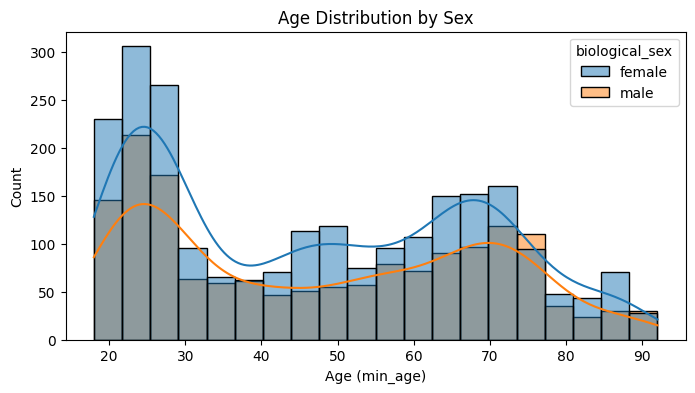

In [17]:
if 'biological_sex' in train_participants.columns:
    train_participants['biological_sex'] = train_participants['biological_sex'].str.lower()

if 'race' in train_participants.columns:
    race_replacements = {
        'race: unknown': 'Unknown',
        'race: other': 'Other',
    }

    train_participants['race'] = train_participants['race'].replace(race_replacements)

print(f"Demographics (train_participants) - Cleaned")

print("\n--- Sex & Race Balance ---")
print(train_participants[['biological_sex', 'race']].value_counts(normalize=True).head(15).to_frame('Percentage'))

print("\n--- Age Statistics ---")
print(train_participants['min_age'].describe().to_frame().T)

# Plot
plt.figure(figsize=(8, 4))
sns.histplot(data=train_participants, x='min_age', hue='biological_sex', kde=True, bins=20)
plt.title("Age Distribution by Sex")
plt.xlabel("Age (min_age)")
plt.show()

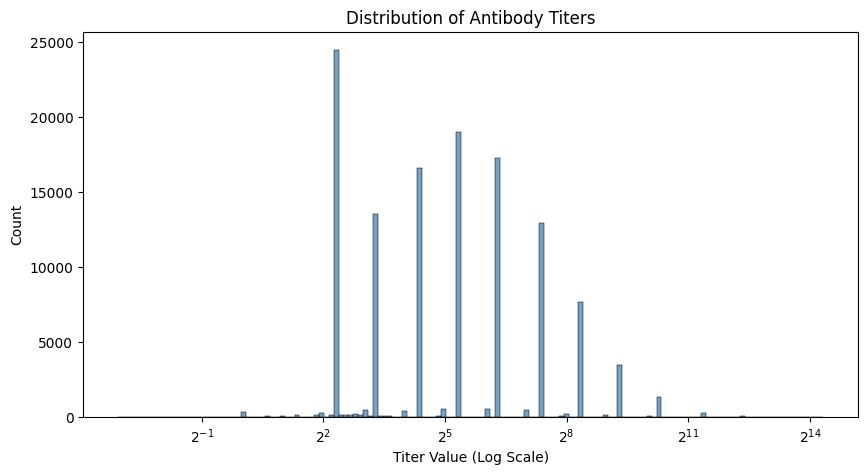

Valid Measurements: 122225
count    122225.000000
mean        106.590364
std         285.507193
min           0.120000
25%          10.000000
50%          40.000000
75%          80.000000
max       20480.000000
Name: value, dtype: float64


In [14]:
train_hai['value'] = pd.to_numeric(train_hai['value'], errors='coerce')

clean_hai = train_hai.dropna(subset=['value'])

plt.figure(figsize=(10, 5))

sns.histplot(data=clean_hai, x='value', log_scale=2, color='steelblue')

plt.title("Distribution of Antibody Titers")
plt.xlabel("Titer Value (Log Scale)")
plt.show()

print(f"Valid Measurements: {len(clean_hai)}")
print(clean_hai['value'].describe())

In [15]:
print(f" Immune Cells (train_flow)")

print("\n--- Top 10 Cell Populations Measured ---")
print(train_flow['name'].value_counts().head(10))

print(f"\nUnique Participants: {train_flow['participant_id'].nunique()}")

 Immune Cells (train_flow)

--- Top 10 Cell Populations Measured ---
name
live CD45+ cells?                                     44126
CD4 T cells                                           20524
CD8 T cells                                           11007
Tfh CXCR5+ CD4 T cell                                  7095
Classical + Intermediate + non-classical monocytes     6572
Th1 CXCR3+ CD4 T cells                                 5300
T cells                                                4953
CD56hi + CD56+ NK cells                                4368
Conventional DCs                                       4214
Plasmacytoid DCs                                       4186
Name: count, dtype: int64

Unique Participants: 264


C:\Users\arvin\AppData\Local\Temp\ipykernel_3196\3529773341.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


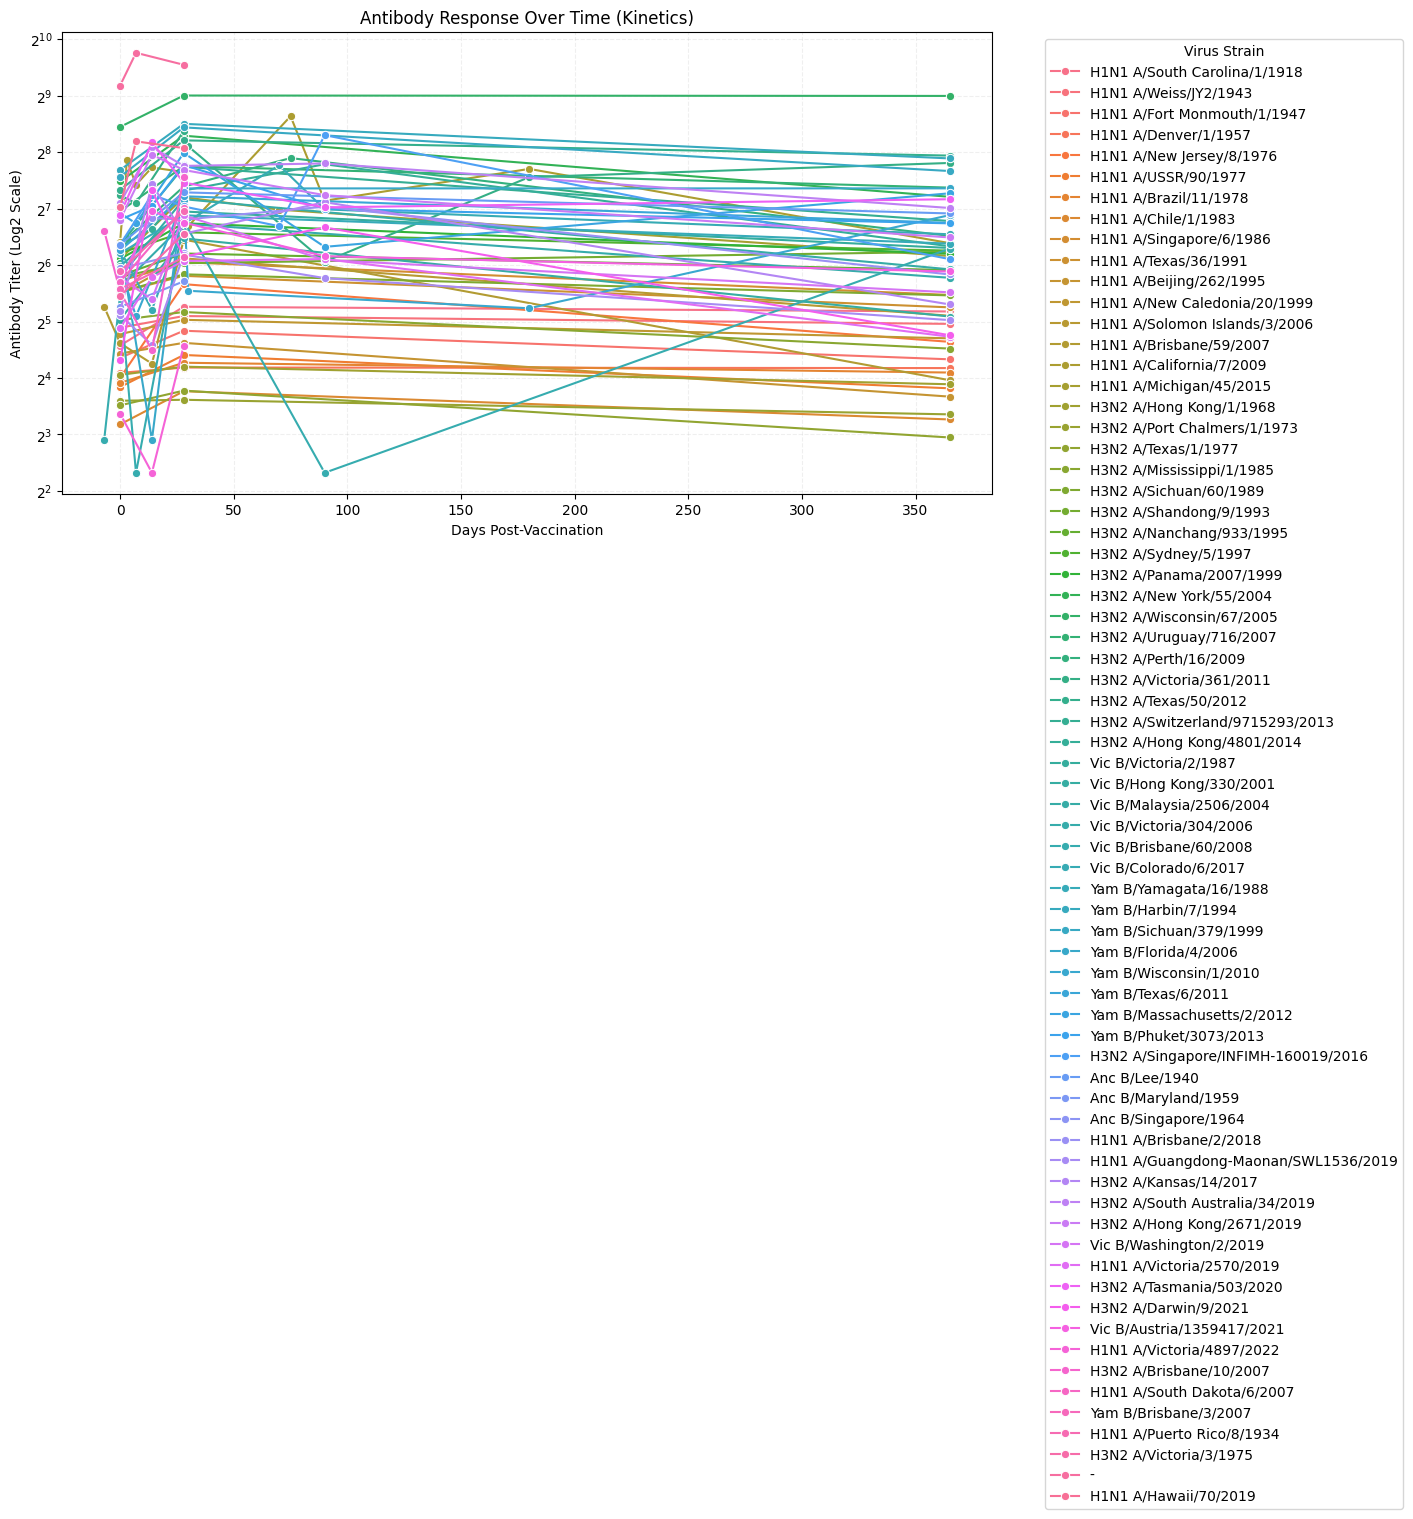

In [20]:
train_hai['value'] = pd.to_numeric(train_hai['value'], errors='coerce')
hai_clean = train_hai.dropna(subset=['value']).copy()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hai_clean, 
    x='timepoint', 
    y='value', 
    hue='virus_strain',
    marker='o',
    errorbar=None
)

plt.yscale('log', base=2)
plt.title("Antibody Response Over Time (Kinetics)")
plt.xlabel("Days Post-Vaccination")
plt.ylabel("Antibody Titer (Log2 Scale)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Virus Strain")
plt.grid(True, which="both", ls="--", alpha=0.2)

plt.tight_layout()
plt.show()

Virus Groups Found:
['H1N1 A' 'H3N2 A' 'Vic B' 'Yam B' 'Anc B' '-']


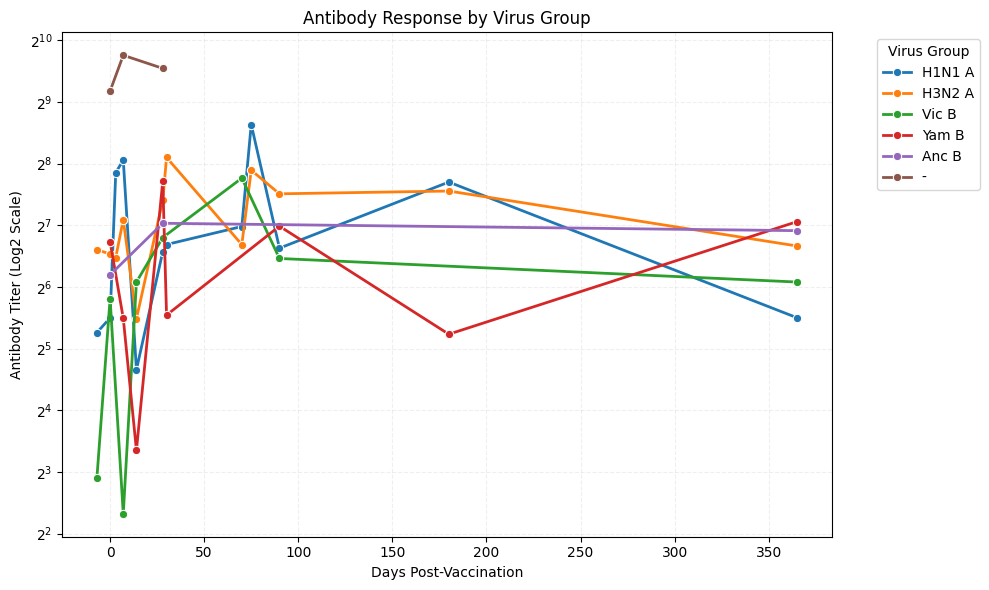

In [22]:
train_hai['value'] = pd.to_numeric(train_hai['value'], errors='coerce')
hai_clean = train_hai.dropna(subset=['value']).copy()

hai_clean['virus_group'] = hai_clean['virus_strain'].astype(str).apply(
    lambda x: x.split('/')[0] if '/' in x else x
)

print("Virus Groups Found:")
print(hai_clean['virus_group'].unique())

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=hai_clean, 
    x='timepoint', 
    y='value', 
    hue='virus_group',
    marker='o',
    linewidth=2,
    errorbar=None
)

plt.yscale('log', base=2)
plt.title("Antibody Response by Virus Group")
plt.xlabel("Days Post-Vaccination")
plt.ylabel("Antibody Titer (Log2 Scale)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Virus Group")
plt.grid(True, which="both", ls="--", alpha=0.2)
plt.tight_layout()
plt.show()